## Customer Churn Prediction

### 1. Business Understanding

#### Problem
SyriaTel is experiencing customer churn, which leads to revenue loss. Retaining existing customers is often more cost-effective than acquiring new ones. Therefore, identifying customers who are likely to stop using SyriaTel’s services allows the company to implement proactive retention strategies

#### Stakeholders
**Executive leaders(CEO/CFO)** - They want to see a reduction in "revenue leak" and a higher Customer Lifetime Value across the board.

**Marketing team** - To see what offers to give to customers likey to churn.

**Customer success** - who want to identify customers at risk of leaving the company.

#### Goal
The goal of this project is to build a classification model that predicts whether a customer will churn. This prediction can help the company take preventive measures to retain customers.

### 2. Data understanding
The datase is a csv file from Kaggle.


In [357]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
import importlib
import evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
importlib.reload(evaluate)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#load the data
data = pd.read_csv('data.csv')
data.head()


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [358]:
# dataset overview
print("\nDataset shape:", data.shape)

print("\nDataset info:")
data.info()




Dataset shape: (3333, 21)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   str    
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   str    
 4   international plan      3333 non-null   str    
 5   voice mail plan         3333 non-null   str    
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total nig

In [359]:
print("Dataset description:")
print(data.describe())

Dataset description:
       account length    area code  number vmail messages  total day minutes  \
count     3333.000000  3333.000000            3333.000000        3333.000000   
mean       101.064806   437.182418               8.099010         179.775098   
std         39.822106    42.371290              13.688365          54.467389   
min          1.000000   408.000000               0.000000           0.000000   
25%         74.000000   408.000000               0.000000         143.700000   
50%        101.000000   415.000000               0.000000         179.400000   
75%        127.000000   510.000000              20.000000         216.400000   
max        243.000000   510.000000              51.000000         350.800000   

       total day calls  total day charge  total eve minutes  total eve calls  \
count      3333.000000       3333.000000        3333.000000      3333.000000   
mean        100.435644         30.562307         200.980348       100.114311   
std          20.06

In [360]:
#check for duplicates
print("\nNumber of duplicate rows:", data.duplicated().sum())



Number of duplicate rows: 0


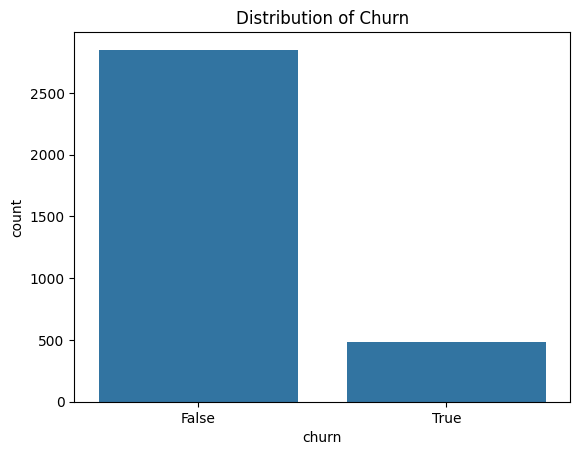

In [361]:
sns.countplot(x="churn", data=data)
plt.title("Distribution of Churn")
plt.show()

### 3. Data preprocessing

#### colleration matrx


<Axes: >

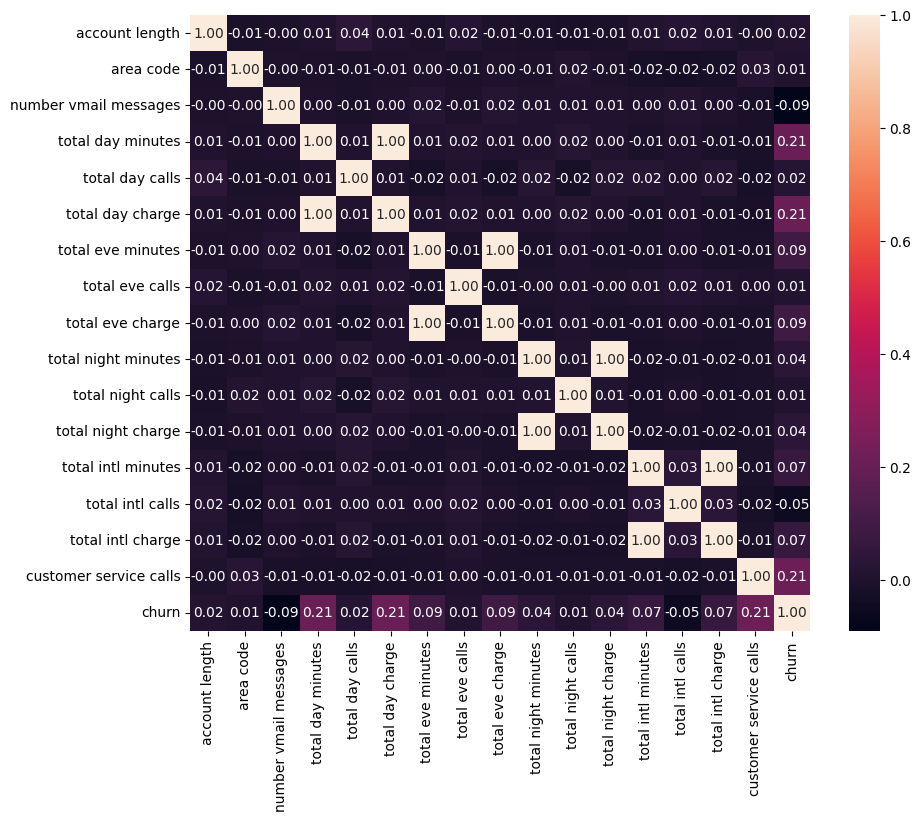

In [362]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='rocket')

The total charge(day, eve, night) have high correlation with the total minutes for day, night and eve.Thos might result to multicollinearity which will led to overfitting when training the data.Thefore need to be dropped.

In [363]:
# dropping columns with high correlation and identifiers
cols_to_drop = [
    "state",
    "phone number",
    "total day charge",
    "total eve charge",
    "total night charge",
    "total intl charge"
]
df_refined = data.drop(columns=cols_to_drop)

#checking the number of features before and after refinement
print(f"Original features: {data.shape[1]}")
print(f"Refined features: {df_refined.shape[1]}")

Original features: 21
Refined features: 15


#### Feature Engineering

In [364]:

df_refined["total_minutes"] = (
    df_refined["total day minutes"] +
    df_refined["total eve minutes"] + #total minutes
    df_refined["total night minutes"]
)
df_refined["total_calls"] = (
    df_refined["total day calls"] +
    df_refined["total eve calls"] + #total calls
    df_refined["total night calls"]
)


In [365]:
#converting target variable to binary
df_refined['churn'] = df_refined['churn'].replace({'True': 1, 'False': 0})

df_refined['churn'] = df_refined['churn'].fillna(0).astype(int)
df_refined['churn'].value_counts()

churn
0    2850
1     483
Name: count, dtype: int64

In [366]:
df_refined.head()

,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls,churn,total_minutes,total_calls
0,128,415,no,yes,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0,707.2,300
1,107,415,no,yes,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0,611.5,329
2,137,415,no,no,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0,527.2,328
3,84,408,yes,no,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0,558.2,248
4,75,415,yes,no,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0,501.9,356


#### train-test split

In [367]:
#separating features and target variable
X = df_refined.drop(columns=['churn'])
y = df_refined['churn']

#splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### pipelines

standardize to make the values on a scale of 0 to 1 and the categorical values to binary

In [368]:
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


In [369]:
# 1. Transform the data (this outputs a NumPy array)
X_transformed = preprocessor.fit_transform(X_train)

# 2. Get the new column names (important for One-Hot encoded columns)
new_column_names = preprocessor.get_feature_names_out()

# 3. Convert back to a DataFrame to inspect
check_df = pd.DataFrame(X_transformed, columns=new_column_names)

# 4. View the first few rows
print(check_df.head())

   num__account length  num__area code  num__number vmail messages  \
0             3.601382        1.735840                   -0.584936   
1             0.184951       -0.517168                   -0.584936   
2            -0.650176       -0.517168                   -0.584936   
3             1.020079       -0.517168                   -0.584936   
4            -0.371801        1.735840                   -0.584936   

   num__total day minutes  num__total day calls  num__total eve minutes  \
0               -1.547653             -0.429657               -0.729987   
1               -1.244014              0.224176               -0.138082   
2                0.787609             -1.133785                2.491952   
3               -0.969818             -0.127888               -0.408385   
4                0.675354             -0.228477                1.294330   

   num__total eve calls  num__total night minutes  num__total night calls  \
0             -1.840891                  1.255804  

#### modeling

In [370]:
# 1. Define your models with names as keys
models = {
    "log_model": LogisticRegression(max_iter=1000),
    "tree_model": DecisionTreeClassifier(random_state=42),
    "rf_model": RandomForestClassifier(n_estimators=200, random_state=42),
    "gb_model": GradientBoostingClassifier(n_estimators=200, random_state=42)
    
}

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline
    
    print(f"Finished training {name}!")
    





Finished training log_model!
Finished training tree_model!
Finished training rf_model!
Finished training gb_model!



==================== Logistic Regression ====================
Accuracy Score: 0.8576

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       566
           1       0.60      0.18      0.27       101

    accuracy                           0.86       667
   macro avg       0.73      0.58      0.60       667
weighted avg       0.83      0.86      0.82       667



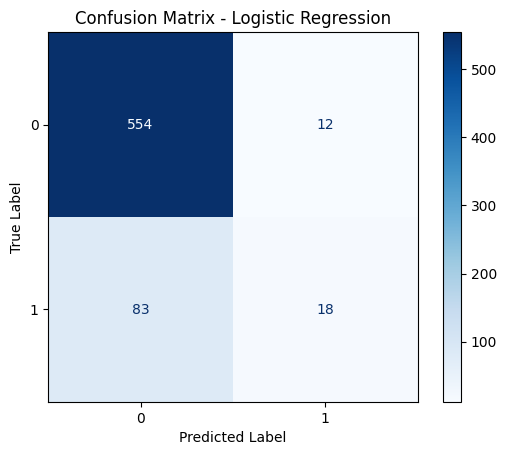

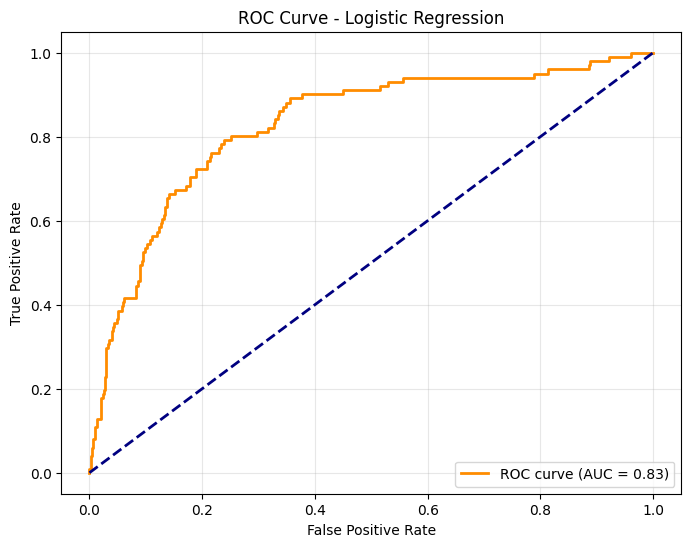


==================== Decision Tree ====================
Accuracy Score: 0.9265

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       566
           1       0.75      0.76      0.76       101

    accuracy                           0.93       667
   macro avg       0.86      0.86      0.86       667
weighted avg       0.93      0.93      0.93       667



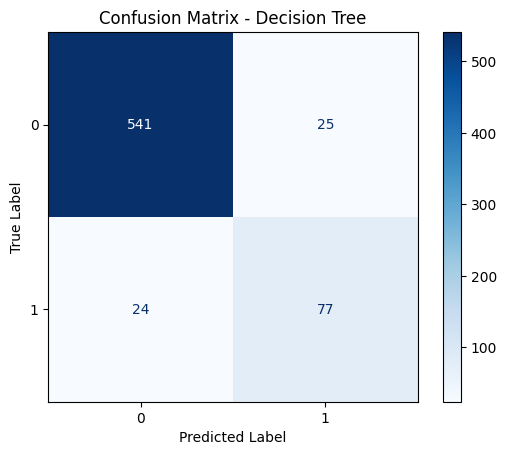

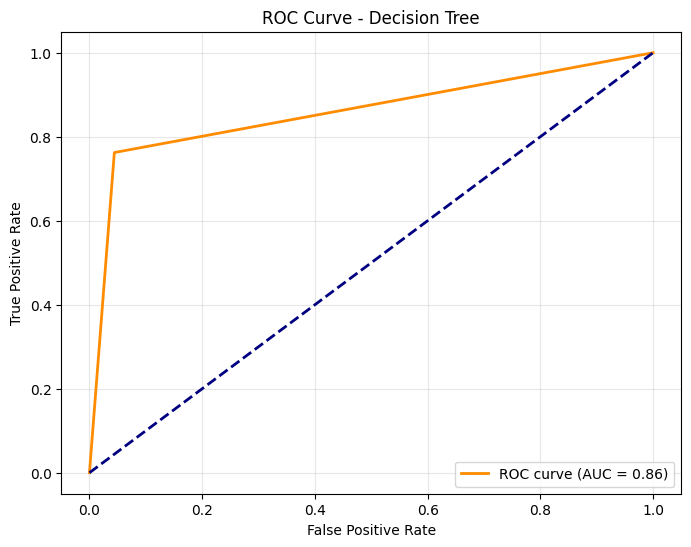


==================== Random Forest ====================
Accuracy Score: 0.9595

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       566
           1       0.97      0.75      0.85       101

    accuracy                           0.96       667
   macro avg       0.97      0.87      0.91       667
weighted avg       0.96      0.96      0.96       667



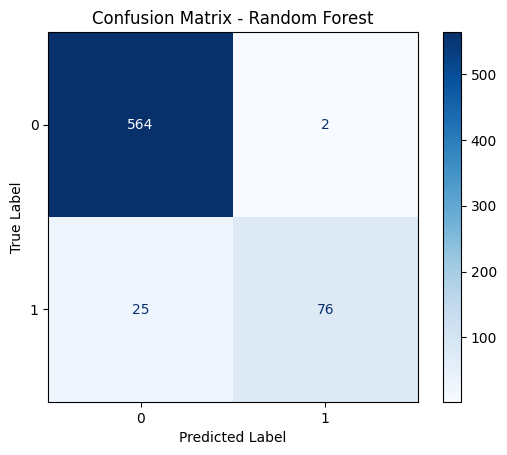

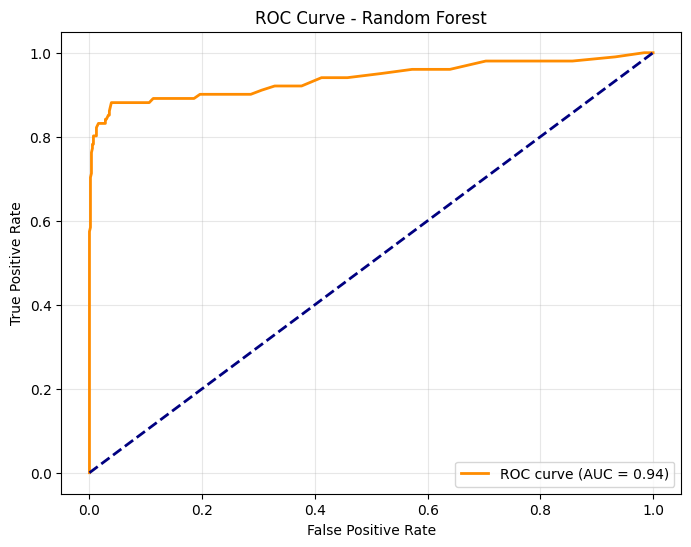


==================== Gradient Boosting ====================
Accuracy Score: 0.9625

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       566
           1       0.95      0.79      0.86       101

    accuracy                           0.96       667
   macro avg       0.96      0.89      0.92       667
weighted avg       0.96      0.96      0.96       667



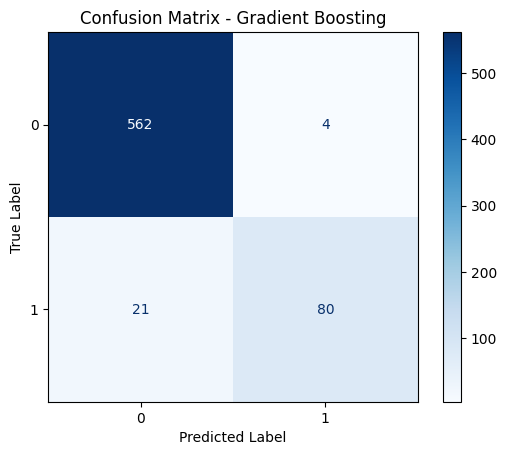

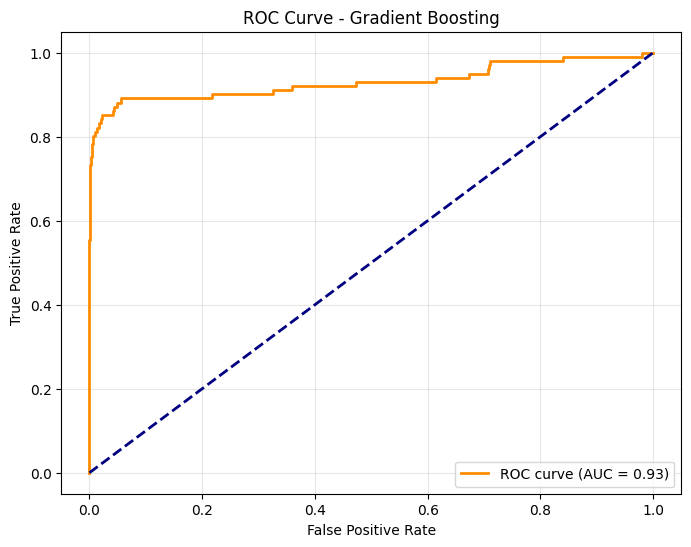

0.9625187406296851

In [371]:
import evaluate

evaluate.evaluate_model("Logistic Regression", trained_models["log_model"], X_test, y_test, True)

evaluate.evaluate_model("Decision Tree", trained_models["tree_model"], X_test, y_test, True)

evaluate.evaluate_model("Random Forest", trained_models["rf_model"], X_test, y_test, True)

evaluate.evaluate_model("Gradient Boosting", trained_models["gb_model"], X_test, y_test, True)



voting classifier


==================== Voting Ensemble ====================
Accuracy Score: 0.9595

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       566
           1       0.99      0.74      0.85       101

    accuracy                           0.96       667
   macro avg       0.97      0.87      0.91       667
weighted avg       0.96      0.96      0.96       667



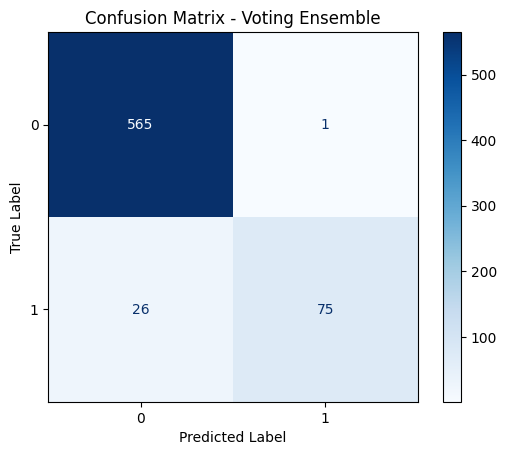

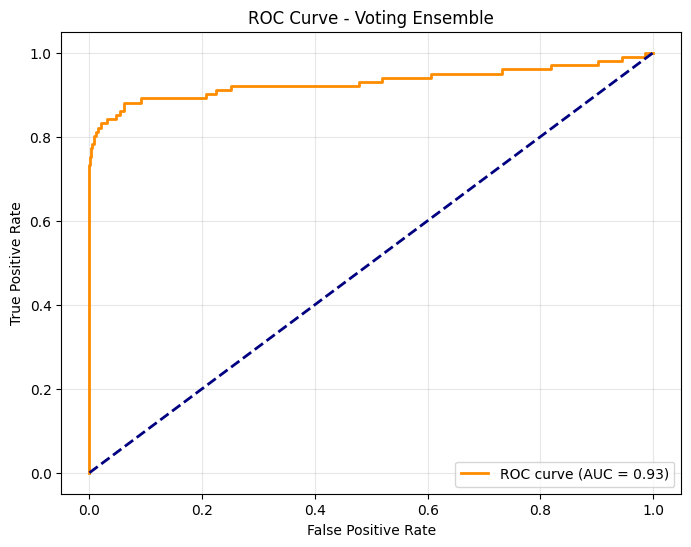

0.95952023988006

In [372]:
voting = VotingClassifier(
    estimators=[
        ("lr", models["log_model"]),
        ("rf", models["rf_model"]),
        ("gb", models["gb_model"])
    ],
    voting="soft"
)
voting_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", voting)
])
voting_pipeline.fit(X_train, y_train)
evaluate.evaluate_model("Voting Ensemble", voting_pipeline, X_test, y_test)

In [373]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
trained_models["voting"] = voting_pipeline
rows = []

for name, model in trained_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

comparison_table = pd.DataFrame(rows)

comparison_table.sort_values("ROC AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
2,rf_model,0.959520,0.974359,0.752475,0.849162,0.938565
3,gb_model,0.962519,0.952381,0.792079,0.864865,0.931113
4,voting,0.959520,0.986842,0.742574,0.847458,0.929678
1,tree_model,0.926537,0.754902,0.762376,0.758621,0.859103
0,log_model,0.857571,0.600000,0.178218,0.274809,0.828062


##### perfomance analysis

- Gradient Boosting (Best for Retention): his is our most effective model for retention. It caught the most churners (80 True Positives) and had the fewest misses (21 False Negatives). It provides the highest "ROI" for a churn prevention campaign.

- Voting Ensemble (Most Precise): This model was the most "cautious," with only 1 False Positive. This means if the model flags a customer as "About to Churn," we can be 98.6% certain they actually are. This is ideal if our retention offers (like discounts or gifts) are very expensive.

- Random Forest : Provided a strong middle ground, maintaining high accuracy and very low false alarms (only 2), making it a highly stable alternative.

- Decision Tree : While it performed better than linear models, it was "noisier," flagging 25 customers incorrectly. This suggests that a single tree is too sensitive to individual data points for this dataset.

- Logistic Regression (Underperformer): This model failed significantly, missing 83 out of 101 churning customers.This makes it not ideal for this problem, especially if detecting class 1 is important.
